In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing required library

In [2]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import shap
import matplotlib.pyplot as plt

In the HAR dataset the X_train, X_test, y_tarin and y_test column names are not included, so there is separate feature.csv file where it has all the feature names, so this code is for adding the column name for the features in the dataset.

In [3]:
import pandas as pd

features = pd.read_csv("/content/drive/MyDrive/HAR_dataset/UCI HAR Dataset/features.csv", header=None)
feature_names = features.iloc[1:, 1].values

X_train = pd.read_csv("/content/drive/MyDrive/HAR_dataset/UCI HAR Dataset/train/X_train.csv", header=None)
y_train = pd.read_csv("/content/drive/MyDrive/HAR_dataset/UCI HAR Dataset/train/y_train.csv", header=None)
X_test  = pd.read_csv("/content/drive/MyDrive/HAR_dataset/UCI HAR Dataset/test/X_test.csv", header=None)
y_test  = pd.read_csv("/content/drive/MyDrive/HAR_dataset/UCI HAR Dataset/test/y_test.csv", header=None)

X_train = X_train.drop(0).reset_index(drop=True)
X_test  = X_test.drop(0).reset_index(drop=True)
y_train = y_train.drop(0).reset_index(drop=True)
y_test  = y_test.drop(0).reset_index(drop=True)

X_train.columns = feature_names          # 561 feature names
X_test.columns  = feature_names
y_train.columns = ["class"]              # manual label name
y_test.columns  = ["class"]

print("✅ Cleaned dataset shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nFirst 5 feature names:", X_train.columns[:560].tolist())
print("Label column name:", y_train.columns[0])


✅ Cleaned dataset shapes:
X_train: (7352, 561)
y_train: (7352, 1)
X_test: (2947, 561)
y_test: (2947, 1)

First 5 feature names: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X', 'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z', 'tBodyAcc-min()-X', 'tBodyAcc-min()-Y', 'tBodyAcc-min()-Z', 'tBodyAcc-sma()', 'tBodyAcc-energy()-X', 'tBodyAcc-energy()-Y', 'tBodyAcc-energy()-Z', 'tBodyAcc-iqr()-X', 'tBodyAcc-iqr()-Y', 'tBodyAcc-iqr()-Z', 'tBodyAcc-entropy()-X', 'tBodyAcc-entropy()-Y', 'tBodyAcc-entropy()-Z', 'tBodyAcc-arCoeff()-X,1', 'tBodyAcc-arCoeff()-X,2', 'tBodyAcc-arCoeff()-X,3', 'tBodyAcc-arCoeff()-X,4', 'tBodyAcc-arCoeff()-Y,1', 'tBodyAcc-arCoeff()-Y,2', 'tBodyAcc-arCoeff()-Y,3', 'tBodyAcc-arCoeff()-Y,4', 'tBodyAcc-arCoeff()-Z,1', 'tBodyAcc-arCoeff()-Z,2', 'tBodyAcc-arCoeff()-Z,3', 'tBodyAcc-arCoeff()-Z,4', 'tBodyAcc-correlation()-X,Y', 'tBodyA

saving once the column name has be included for all the train and test dataset

In [4]:
# Save cleaned datasets as CSV in the current working directory
X_train.to_csv("X_train_clean.csv", index=False)
y_train.to_csv("y_train_clean.csv", index=False)
X_test.to_csv("X_test_clean.csv", index=False)
y_test.to_csv("y_test_clean.csv", index=False)

print("✅ Cleaned CSV files saved successfully in current directory!")

✅ Cleaned CSV files saved successfully in current directory!


this code is to show the size dataset

In [7]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import shap
import matplotlib.pyplot as plt

# Load the cleaned data
X_train = pd.read_csv("X_train_clean.csv")
y_train = pd.read_csv("y_train_clean.csv")
X_test  = pd.read_csv("X_test_clean.csv")
y_test  = pd.read_csv("y_test_clean.csv")

print("Shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Shapes:
X_train: (7352, 561)
y_train: (7352, 1)
X_test: (2947, 561)
y_test: (2947, 1)


training is done using Random forest classifier which shows 92.36% accuracy.

In [8]:
model = RandomForestClassifier(n_estimators=200, max_depth=10)
model.fit(X_train, y_train.values.ravel())  # .ravel() converts (n,1) -> (n,)


y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9236511706820495

Classification Report:
               precision    recall  f1-score   support

           1       0.88      0.98      0.93       496
           2       0.90      0.91      0.90       471
           3       0.96      0.83      0.89       420
           4       0.91      0.89      0.90       491
           5       0.90      0.92      0.91       532
           6       1.00      1.00      1.00       537

    accuracy                           0.92      2947
   macro avg       0.92      0.92      0.92      2947
weighted avg       0.93      0.92      0.92      2947



Confusion metrix to know the TP, TN, FP and FN

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion metrix of HAR dataset: ")
print(cm)

Confusion metrix of HAR dataset: 
[[484   3   9   0   0   0]
 [ 37 428   6   0   0   0]
 [ 26  47 347   0   0   0]
 [  0   0   0 438  53   0]
 [  0   0   0  44 488   0]
 [  0   0   0   0   0 537]]


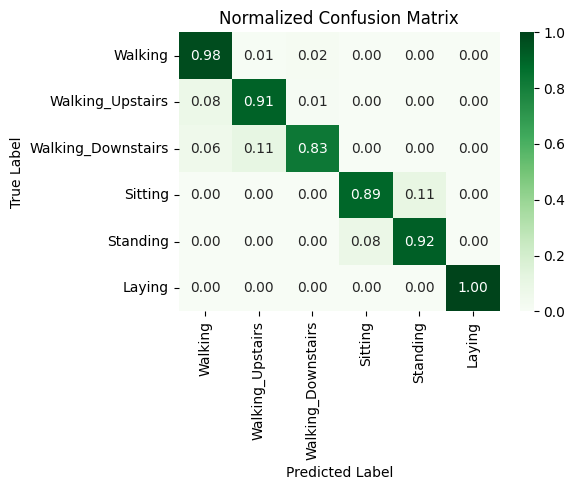

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = ["Walking", "Walking_Upstairs", "Walking_Downstairs", "Sitting", "Standing", "Laying"]

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=labels, yticklabels=labels)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

Now i am using the SHAP XAI technique, as there 561 feature and 6 class in the dataset, instead of using all the 561 feature by using SHAP will give most important feature which can be used for further training. Next by using only those important feature which are obtained from the SHAP are used for classification. As i have shown 170 important feature from the 561 feature.

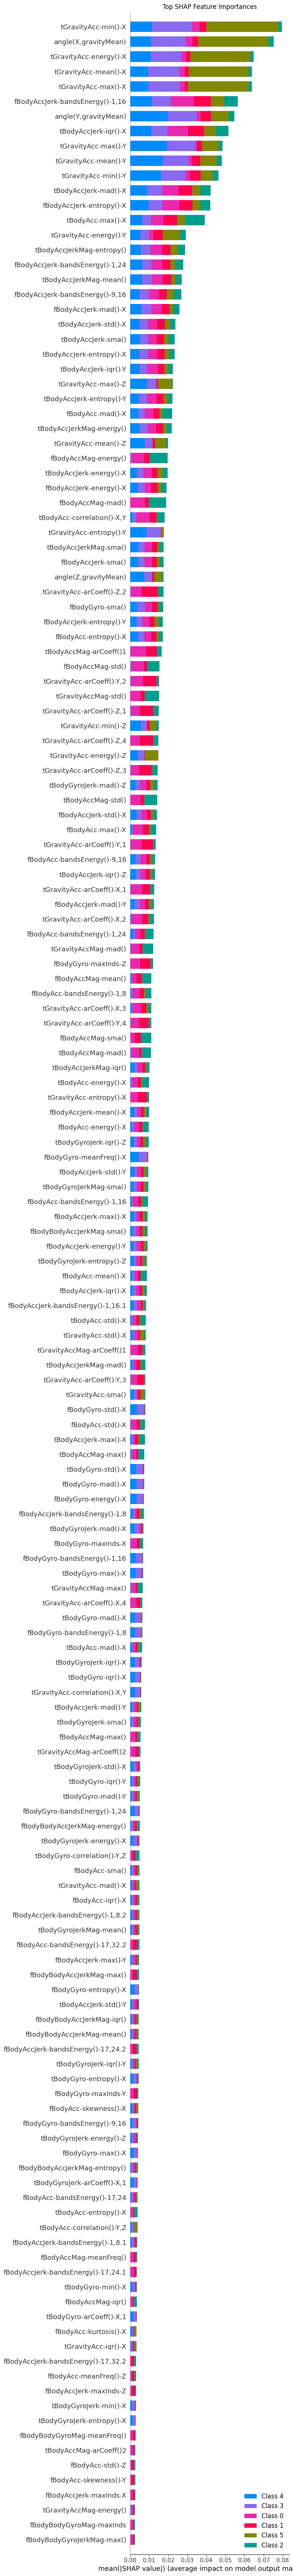

In [15]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

plt.title("Top SHAP Feature Importances")
shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=170)

From above graph you can see that SHAP feature from 561 feature, I have used top 100 feature to train and test to see how much difference we get in the accuracy and the confusion metrix. as can be seen for 100 feature obtained 89.82%. if you want to increase and decrease the number of feature number can be chnaged and trained and tested.

In [18]:
import numpy as np
import pandas as pd

print("shap_values shape:", np.array(shap_values).shape)


shap_array = np.abs(shap_values)
shap_mean = shap_array.mean(axis=(0, 2))

print("shap_mean shape:", shap_mean.shape)
print("X_train columns length:", len(X_train.columns))


shap_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Mean |SHAP|': shap_mean
}).sort_values(by='Mean |SHAP|', ascending=False)


top_features = shap_importance_df['Feature'].head(100).values
print("Top 170 SHAP features selected:", len(top_features))
print(shap_importance_df.head(10))


X_train_reduced = X_train[top_features]
X_test_reduced = X_test[top_features]

print("Reduced training shape:", X_train_reduced.shape)
print("Reduced testing shape:", X_test_reduced.shape)


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model_reduced = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model_reduced.fit(X_train_reduced, y_train.values.ravel())


y_pred_reduced = model_reduced.predict(X_test_reduced)
print("Accuracy with Top 100 SHAP features:", accuracy_score(y_test, y_pred_reduced))
print("\nClassification Report (Reduced Model):\n", classification_report(y_test, y_pred_reduced))

shap_values shape: (7352, 561, 6)
shap_mean shape: (561,)
X_train columns length: 561
Top 170 SHAP features selected: 100
                             Feature  Mean |SHAP|
52               tGravityAcc-min()-X     0.013255
558             angle(X,gravityMean)     0.012565
56            tGravityAcc-energy()-X     0.010800
40              tGravityAcc-mean()-X     0.010634
49               tGravityAcc-max()-X     0.010631
389  fBodyAccJerk-bandsEnergy()-1,16     0.009425
559             angle(Y,gravityMean)     0.009113
99              tBodyAccJerk-iqr()-X     0.008599
50               tGravityAcc-max()-Y     0.008076
41              tGravityAcc-mean()-Y     0.008010
Reduced training shape: (7352, 100)
Reduced testing shape: (2947, 100)
Accuracy with Top 100 SHAP features: 0.8982015609093994

Classification Report (Reduced Model):
               precision    recall  f1-score   support

           1       0.86      0.97      0.91       496
           2       0.88      0.88      0.88       4

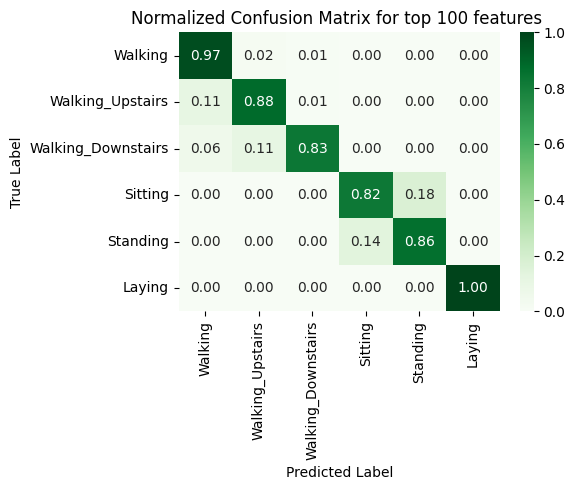

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Generate confusion matrix ---
cm = confusion_matrix(y_test, y_pred_reduced)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalize row-wise

# --- Define class labels (HAR dataset has 6) ---
labels = ["Walking", "Walking_Upstairs", "Walking_Downstairs", "Sitting", "Standing", "Laying"]

# --- Plot heatmap ---
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=labels, yticklabels=labels)
plt.title("Normalized Confusion Matrix for top 100 features ")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

this is for example see the reduced/selected top feature from the 561 feature.

In [ ]:
print("Reduced Training Data Shape:", X_train_reduced.shape)
print("Reduced Testing Data Shape:", X_test_reduced.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)